# Report on Biological Computation
**Student Name:** REENU KOSHY  
**Student ID:** 525342833  
**Date:** April 2026

In [27]:
import pandas as pd
import glob
import numpy as np

In [16]:
def analyze_gene(filename):
    df = pd.read_csv(filename, sep='\t')
    wt_dna = df['WildType.Sequence'].values[0]
    mut_dna = df['Mutant.Sequence'].values[0]
    
    # Slicing
    promoter = wt_dna[:1000]
    
    # Logic
    if len(wt_dna) == len(mut_dna):
        m_type = "sub"
    elif len(mut_dna) > len(wt_dna):
        m_type = "ins"
    else:
        m_type = "del"
        
    # Math
    mrna_wt = df[['mRNA.Expression.WT.Rep1', 'mRNA.Expression.WT.Rep2', 'mRNA.Expression.WT.Rep3']].mean(axis=1).values[0]
    mrna_mut = df[['mRNA.Expression.Mut.Rep1', 'mRNA.Expression.Mut.Rep2', 'mRNA.Expression.Mut.Rep3']].mean(axis=1).values[0]
    

    return {
        'Gene': df['Gene'].values[0],
        'Mutation_Class': m_type,
        'mRNA_WT_Avg': mrna_wt,
        'mRNA_Mut_Avg': mrna_mut,
        'Promoter': promoter
    }

In [12]:
import os
import glob
import pandas as pd

# 1. Access the 'reenu' folder in Downloads
path = os.path.join(os.path.expanduser("~"), "Downloads", "reenu")
os.chdir(path)

# 2. Search for all text files
files = glob.glob("*.txt")

# 3. Use a loop to process all 24 files
results = []
for f in files:
    try:
        # Calls the function you defined in Cell 2
        gene_data = analyze_gene(f)
        results.append(gene_data)
    except:
        # Skips non-data files (like system files)
        continue

# 4. Create and display the Master Table
master_table = pd.DataFrame(results)

print(f"Task 1: Master Table generated with {len(master_table)} genes.")
master_table

Task 1: Master Table generated with 24 genes.


,Gene,Mutation_Class,mRNA_WT_Avg,mRNA_Mut_Avg,Promoter
0,Ah3,sub,1.061045e+08,1.061045e+08,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...
1,Alli8,sub,2.765717e+01,2.692833e+01,TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...
2,Anap7c1,sub,9.957710e+00,-3.957048e+01,GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...
3,App1l8,ins,4.057949e+00,3.632353e+00,ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...
4,Avon4,ins,2.512790e+00,3.958356e+00,TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...
5,Cairn3a2,sub,2.536683e+01,2.574975e+01,GCACTATGGAACAAATCTCCGTAGGATAGCCAGAGTAAATCGGCCT...
6,Cairn6,sub,1.757151e+03,1.757414e+03,GATTGCTAGTGGTAGTGGTGGCCCGGGTCGCCGTCCGCCACTCTTT...
7,Clach6,sub,8.647071e+00,7.966945e+00,AAATGACATCCTCCGGGGAACGATGCAGGCCCAGTAAGCCAATACT...
8,Dsgt9a1,ins,3.790932e+01,4.167821e+01,ATAATCGCTGGTGTACTTCAAGTTACGACTTGAGTACGCATATCCA...
9,Ever6b6,del,1.059454e+06,1.059454e+06,AAGTTATTCTACGGGCCCTCTATTGAATAGATAACCCAGGGGCGTG...


In [13]:
# 1. Calculate the absolute difference between Wild Type and Mutant expression
master_table['Expression_Change'] = abs(master_table['mRNA_WT_Avg'] - master_table['mRNA_Mut_Avg'])

# 2. Sort the table by that change (highest at the top)
top_5_prioritized = master_table.sort_values(by='Expression_Change', ascending=False).head(5)

# 3. Display the results for the report
print("--- TASK 2: TOP 5 GENES FOR VALIDATION ---")
print(top_5_prioritized[['Gene', 'Mutation_Class', 'Expression_Change']])

--- TASK 2: TOP 5 GENES FOR VALIDATION ---
       Gene Mutation_Class  Expression_Change
13   Ist9a2            del        5010.362690
2   Anap7c1            sub          49.528187
8   Dsgt9a1            ins           3.768895
17   Jok4a3            sub           1.577621
4     Avon4            ins           1.445566


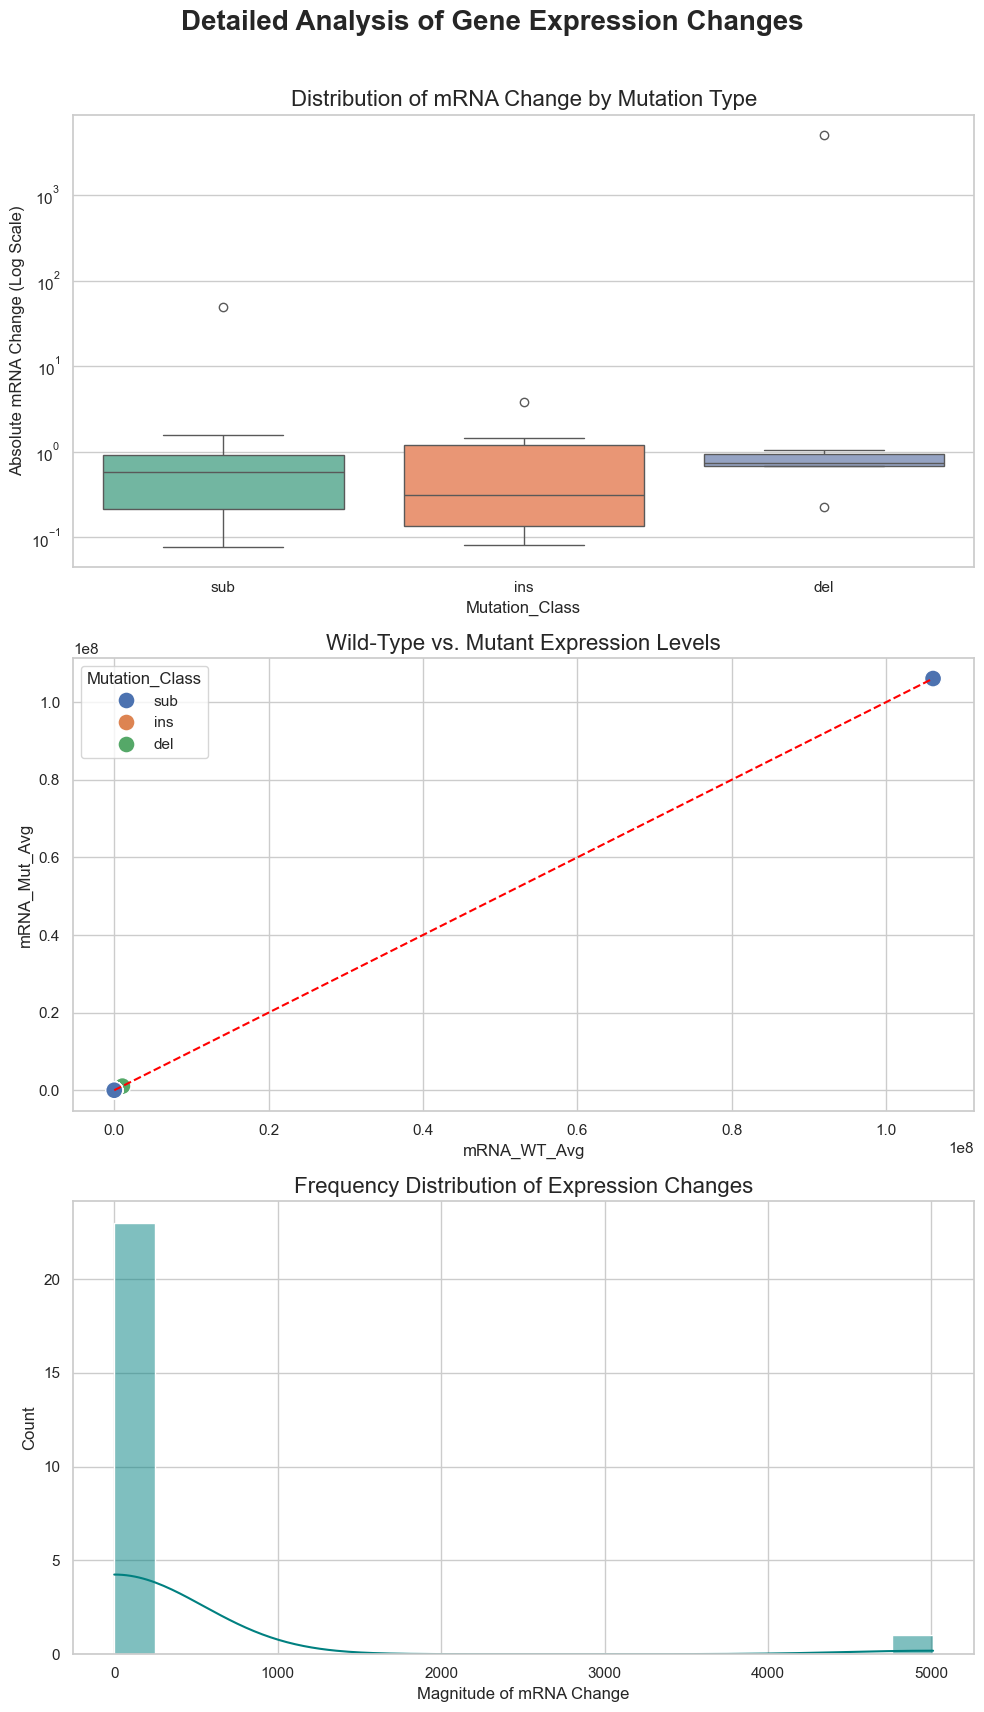

In [15]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the style
sns.set_theme(style="whitegrid")

# 2. Create the figure with 3 rows instead of 3 columns
# We change (1, 3) to (3, 1) and increase the height (figsize)
fig, axes = plt.subplots(3, 1, figsize=(10, 18))
fig.suptitle('Detailed Analysis of Gene Expression Changes', fontsize=20, fontweight='bold')

# PANEL 1: Boxplot (Large view)
sns.boxplot(ax=axes[0], x='Mutation_Class', y='Expression_Change', 
            data=master_table, hue='Mutation_Class', palette='Set2', legend=False)
axes[0].set_title('Distribution of mRNA Change by Mutation Type', fontsize=16)
axes[0].set_yscale('log') 
axes[0].set_ylabel('Absolute mRNA Change (Log Scale)')

# PANEL 2: Scatter Plot (Large view)
sns.scatterplot(ax=axes[1], x='mRNA_WT_Avg', y='mRNA_Mut_Avg', 
                hue='Mutation_Class', data=master_table, s=150)
# Adding the diagonal "No Change" line
max_val = max(master_table['mRNA_WT_Avg'].max(), master_table['mRNA_Mut_Avg'].max())
axes[1].plot([0, max_val], [0, max_val], color='red', linestyle='--')
axes[1].set_title('Wild-Type vs. Mutant Expression Levels', fontsize=16)

# PANEL 3: Histogram/Density (Large view)
sns.histplot(ax=axes[2], data=master_table, x='Expression_Change', 
             kde=True, color='teal', bins=20)
axes[2].set_title('Frequency Distribution of Expression Changes', fontsize=16)
axes[2].set_xlabel('Magnitude of mRNA Change')

# Adjust spacing so titles don't overlap
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()